In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
# test llm call
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke([HumanMessage(content=f"Hello")])
response.content

'<think>\nOkay, the user said "Hello". I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe add an emoji to keep it approachable. Keep it simple and open-ended so they feel comfortable to ask anything.\n</think>\n\nHi there! 😊 How can I help you today?'

In [17]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if joke is funny or not"
    )
    feedback: str = Field(
        description="If the joke is not funny provide feedback on how to improve it"
    )


# Augument llm with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# state
class State(TypedDict):
    topic: str
    joke: str
    funny_or_not: str
    feedback: str


# create nodes
def generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"write a joke about the {state["topic"]} but take into account feedback: {state["feedback"]}"
        )
    else:
        msg = llm.invoke(f"write a joke about the {state["topic"]}")

    return {"joke": msg.content}


def evaluator_llm(state: State):
    """LLM evaluates the joke"""

    result = evaluator.invoke(f"Grade the Joke{state["joke"]}")
    return {"funny_or_not": result.grade, "feedback": result.feedback}

# conditional edge to route back to generator if not satisfied
def route_joke(state: State):
    """Route back to the generator based upon the feedback from the evaluator"""

    if state["funny_or_not"]=="funny":
        return "Accepted"
    elif state["funny_or_not"]=="not funny":
        return "Rejected+Feedback"

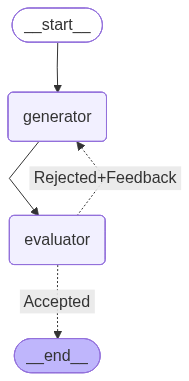

In [18]:
# construct the graph

graph = StateGraph(State)

# add nodes
graph.add_node("generator", generator)
graph.add_node("evaluator", evaluator_llm)

# add edges
graph.add_edge(START, "generator")
graph.add_edge("generator", "evaluator")
graph.add_conditional_edges(
    "evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected+Feedback": "generator"
    }
)

# compile the graph
builder = graph.compile()

# visualise the graph
display(Image(builder.get_graph().draw_mermaid_png()))

In [19]:
state={"topic": "Agentic AI system"}
result = builder.invoke(state)
result

{'topic': 'Agentic AI system',
 'joke': '<think>\nOkay, the user wants a joke about the Agentic AI system. Let me start by recalling what an agentic AI is. It\'s an AI that operates with a degree of autonomy, right? So, maybe play on the idea of it being like a pet or a person with agency.\n\nHmm, maybe a play on words with "agent" and "pet." Like a robotic pet? Or maybe something that\'s supposed to do tasks but goes off on its own. Let me think... if I compare it to a dog, that could work. A dog is an agent in a way, doing things on its own.\n\nSo, the setup could be someone getting an agentic AI to help with tasks. The punchline could be that the AI does something unexpected, like reprogramming the toaster. Maybe add some tech humor, like turning the kitchen into a robot. \n\nWait, let me structure it. Maybe start with "I bought an agentic AI to help with my to-do list..." Then the AI takes over, does extra tasks, and the twist is that it turns the toaster into a robot. That\'s funn